In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# target_row = 180
target_row = 150
target_rows = [200, 180, 150]

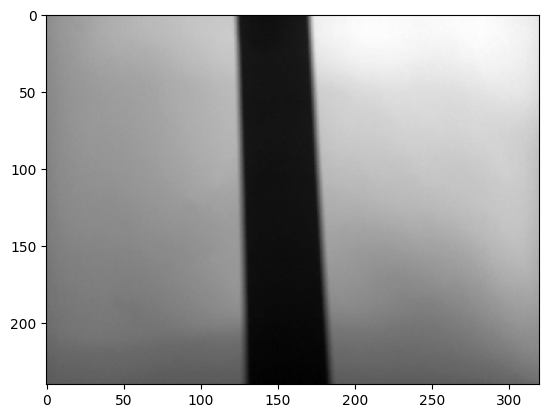

In [13]:
image = cv2.imread('line_1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")

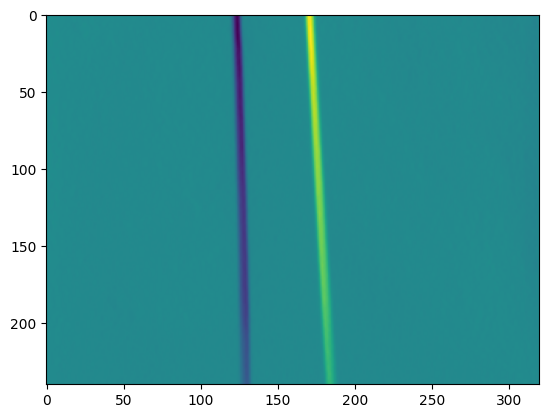

In [14]:
diffs = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
plt.imshow(diffs)

In [70]:
def sobel_for_image(filename, ksize=3):
    image = cv2.imread(filename)
    resized = cv2.resize(image, (320, 240))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.blur(gray, (9, 9), 0)
    diffs = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=ksize)
    return diffs

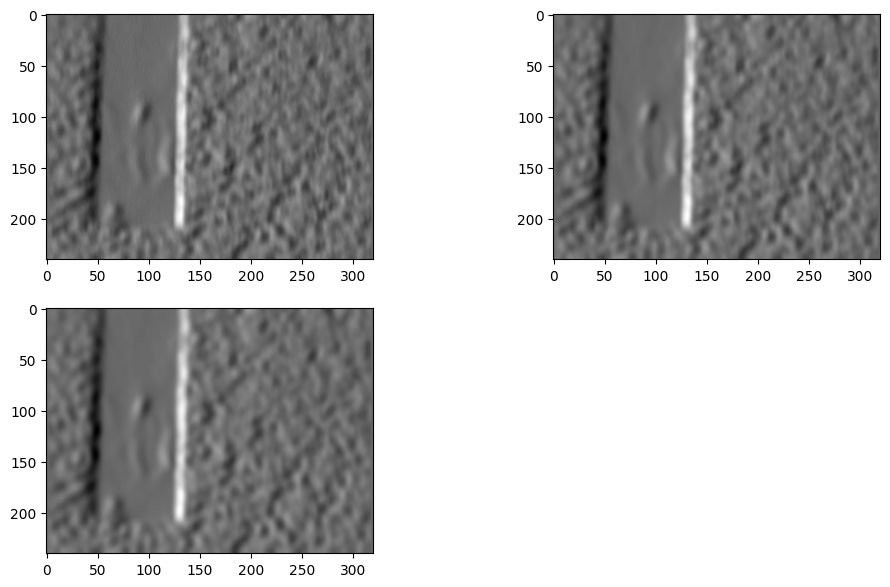

In [71]:
plt.figure(figsize=(12, 7))
plt.subplot(2, 2, 1)
plt.imshow(sobel_for_image('carpet_line1.jpg', ksize=3),cmap="gray")
plt.subplot(2, 2, 2)
plt.imshow(sobel_for_image('carpet_line1.jpg', ksize=9),cmap="gray")
plt.subplot(2, 2, 3)
plt.imshow(sobel_for_image('carpet_line1.jpg', ksize=15),cmap="gray")


Number of channels in sobel: 1
Pixel intensity range in sobel: -107.0 to 153.0
Mean: 1.5830989583333335, Stddev: 23.36806538804166


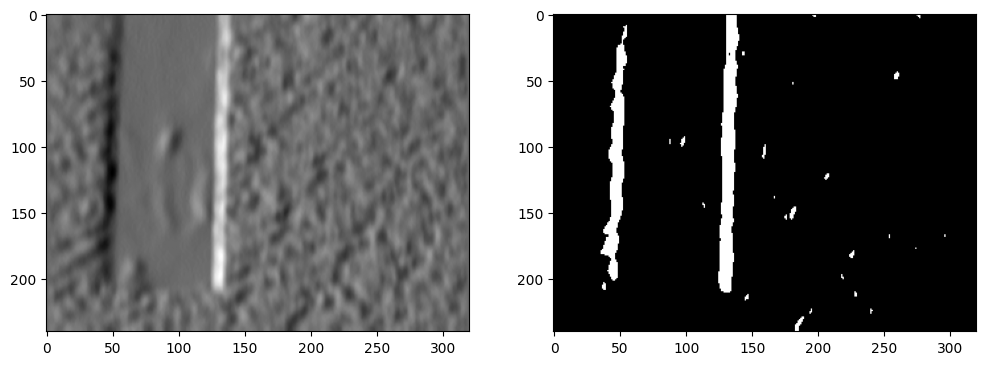

In [75]:
# outliers

def get_outliers(image, n_std_devs = 3):
    # Image should be greycscale at this point
    mean, stddev = cv2.meanStdDev(image)
    mean = mean[0][0]
    stddev = stddev[0][0]
    print(f"Mean: {mean}, Stddev: {stddev}")
    bright_mask = cv2.inRange(image, mean + stddev * n_std_devs, image.max())
    dark_mask = cv2.inRange(image, image.min(), mean - stddev * n_std_devs)
    # # combine the masks into a single mask
    both = cv2.bitwise_or(bright_mask, dark_mask)
    return both

sobel = sobel_for_image('carpet_line1.jpg', ksize=3)

# print the number of channels in sobel
print("Number of channels in sobel:", sobel.shape[2] if len(sobel.shape) > 2 else 1)
# What range are the pixel intensities in?
print("Pixel intensity range in sobel:", sobel.min(), "to", sobel.max())

outliers = get_outliers(sobel, n_std_devs=2)
plt.figure(figsize=(12, 7))
plt.subplot(1, 2, 1)
plt.imshow(sobel,cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(outliers, cmap="gray")


In [31]:
def canny_for_image(filename, apertureSize=3):
    image = cv2.imread(filename)
    resized = cv2.resize(image, (320, 240))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200, apertureSize=apertureSize)
    return edges

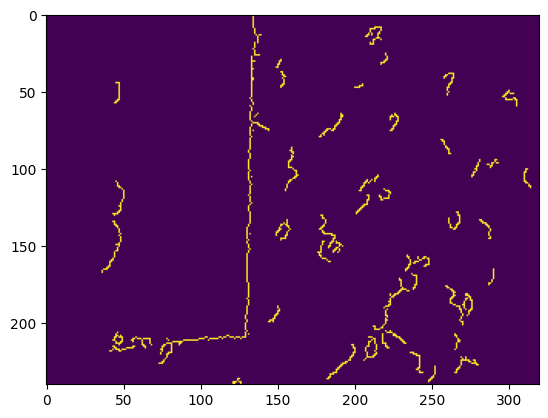

In [41]:
plt.imshow(canny_for_image('carpet_line1.jpg', apertureSize=3))

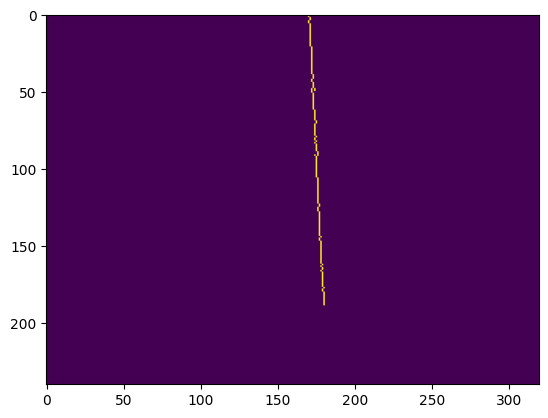

In [44]:
plt.imshow(canny_for_image('line_1.jpg', apertureSize=3))

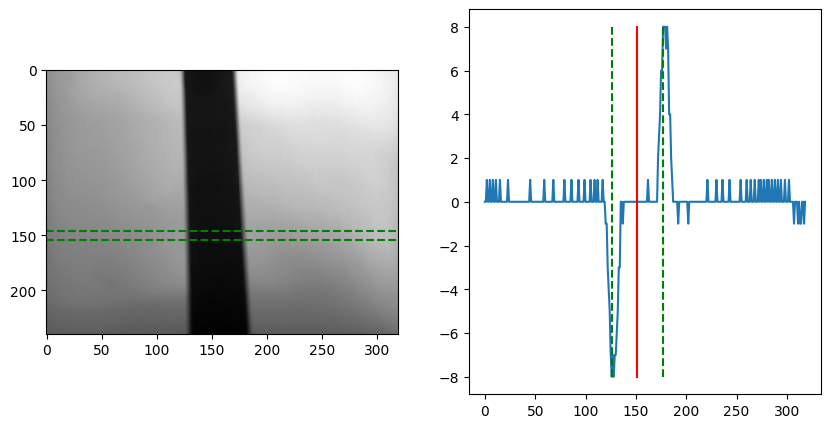

In [74]:
def plot_diffs(image_name):
    image = cv2.imread(image_name)
    resized = cv2.resize(image, (320, 240))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.blur(gray, (10, 10), 0)
    row = blurred[target_row].astype(np.int32)
    diff = np.diff(row)
    plot_image_and_diff(gray, diff)

    max_d = np.amax(diff)
    min_d = np.amin(diff)
    highest = np.where(diff == max_d)[0][0]
    lowest = np.where(diff == min_d)[0][0]

    if max_d < 5 or min_d > -5:
        print("No line")
        return

    middle = (highest + lowest) / 2
    
    plt.plot([lowest, lowest], [max_d, min_d], "g--")
    plt.plot([highest, highest], [max_d, min_d], "g--")
    plt.plot([middle, middle], [max_d, min_d], "r-")
plot_diffs("line_1.jpg")

No line


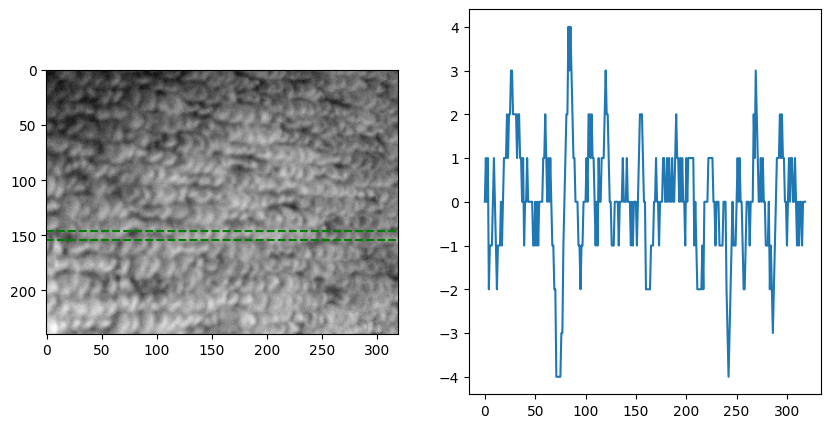

In [75]:
plot_diffs("empty_carpet.jpg")

No line


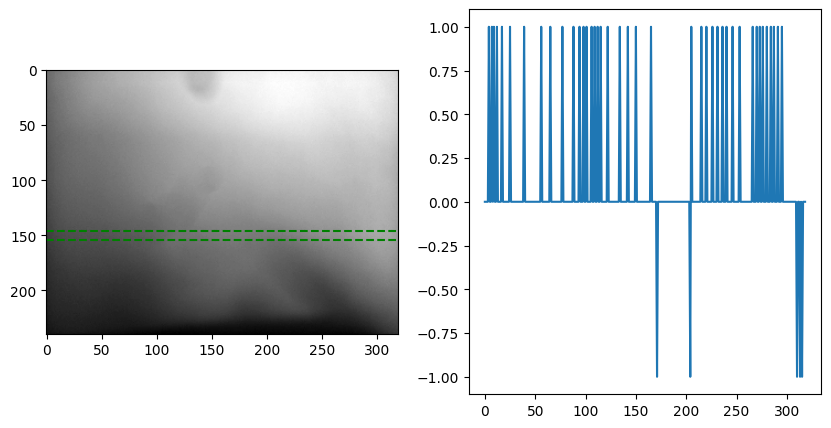

In [76]:
plot_diffs("empty_gray.jpg")

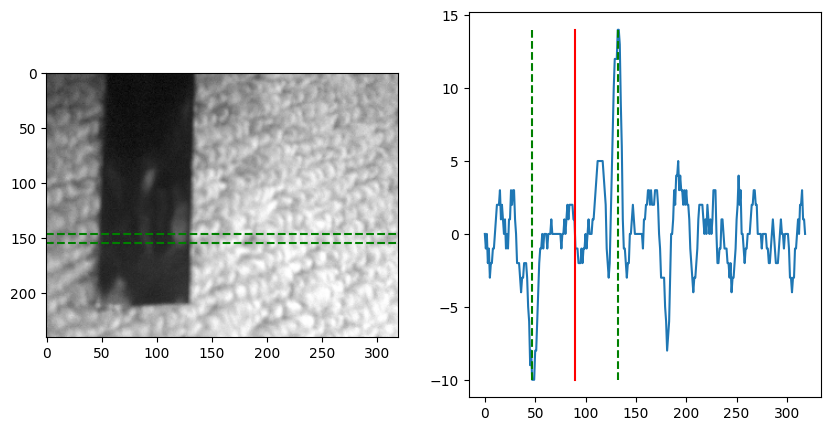

In [77]:
plot_diffs('carpet_line1.jpg')

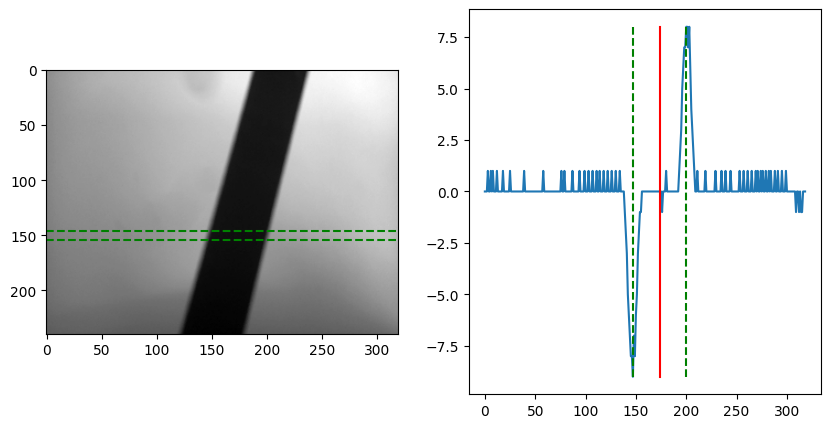

In [78]:
plot_diffs("line_2.jpg")

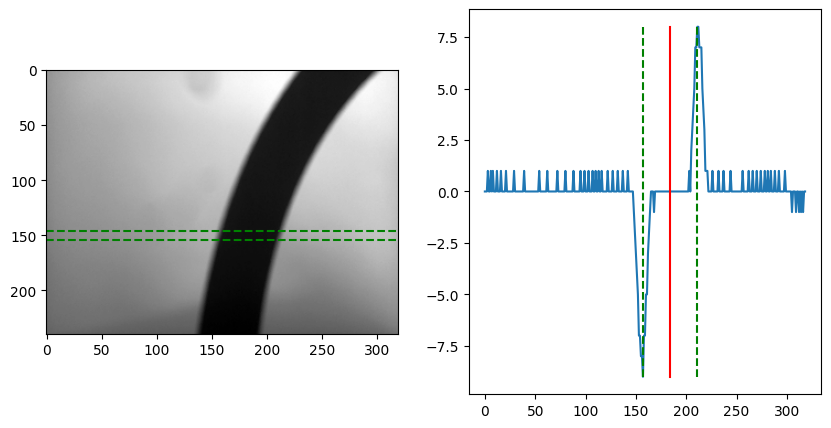

In [79]:
plot_diffs("line_3.jpg")

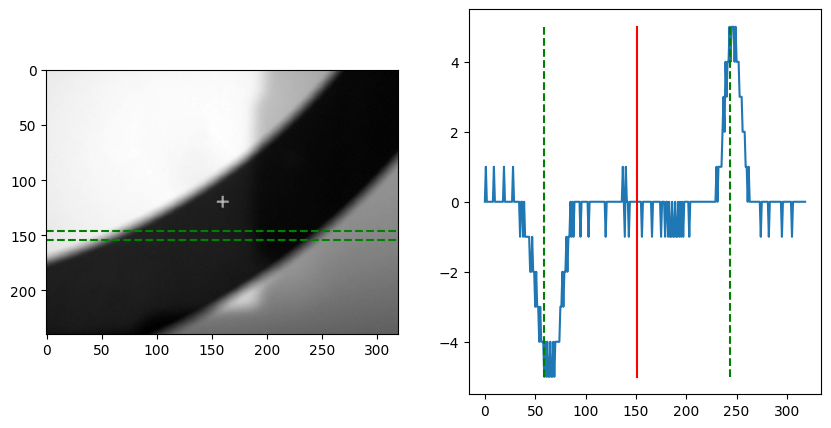

In [85]:
plot_diffs("line-it-missed.jpg")

No line


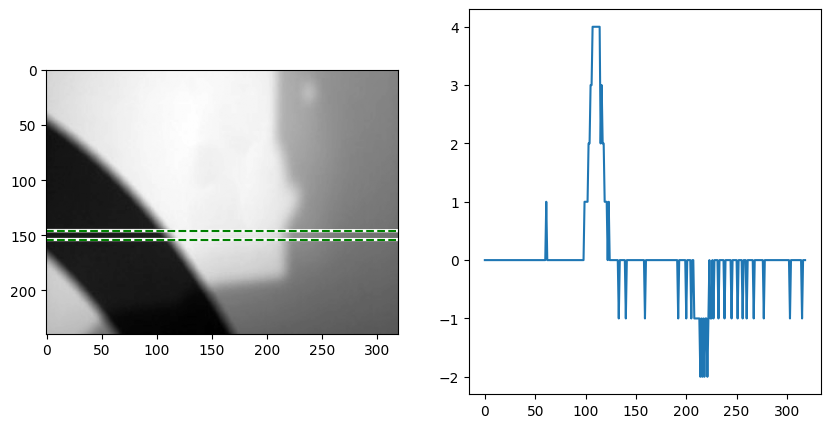

In [86]:
plot_diffs("Pasted image 20250810205801.jpg")